# why_not_faces — the case for the paper, and why

The sixth and final image-stream experiment. Every prior arm bounded one
confound at a time: `blurred_images` (texture), `background_images`
(framing, at first overstated -- see `face_crop_blur`'s Part 0),
`face_crop_blur` (resampling), `face_landmarks` (facial shape itself,
tested directly and found weakly, pose-entangled positive). This
experiment assembles the case: a named-feature model interpretable
enough for SHAP to explain in words, and a properly fine-tuned CNN run
under two protocols, so the published-literature-style number and the
honest number are both on the record, side by side.

Two models, deliberately different purposes:

1. **A named-feature model** on the ~30 interpretable features already
   computed across every previous experiment. SHAP over it answers "what
   is the classifier actually using?" in words a supervisor can read.
2. **A fine-tuned CNN** -- DenseNet201, ImageNet weights, every parameter
   trainable -- the method the literature uses, run correctly, so nobody
   can argue the negative result is an artefact of using a weak model.

Everything here reuses cached artefacts: features, boxes, landmarks,
embeddings. No image is re-detected, no landmark re-extracted -- the only
new extraction in this entire experiment is the CNN's own training.

## 1. Imports, config, device check

In [1]:
import logging
import random
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)

from experiments.why_not_faces.config import Config, FEATURE_GROUPS
from experiments.why_not_faces.pipeline import (
    step_1_manifest,
    step_2_assemble_features,
    step_3_named_feature_probes,
    step_4_probe_summary,
    step_5_shap_out_of_fold,
    verify_out_of_fold,
    step_6_group_attribution,
    step_7_stability_check,
    step_8_consolidated_table,
)
from experiments.why_not_faces.cnn import (
    build_model,
    run_published_protocol,
    load_corrected_protocol_manifest,
    run_corrected_protocol,
    GradCAM,
    gradcam_off_face_fraction,
    run_gradcam_analysis,
)

C:\Projects\Autism Screening\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = Config()
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print()
print("Note on reproducibility: seeds are fixed throughout, including for the CNN,")
print("but exact bit-for-bit reproducibility of the CNN's training is not guaranteed on GPU")
print("(some cuDNN kernels remain non-deterministic even with cudnn.deterministic=True).")
print("Every other arm in this notebook (named-feature probes, SHAP) is fully deterministic.")
print()
print(f"feature groups: {list(FEATURE_GROUPS)}")
print(f"cnn_backbone: {cfg.cnn_backbone}, image_size: {cfg.cnn_image_size}")
print(f"cnn_n_folds (corrected protocol): {cfg.cnn_n_folds} (a single repeat -- see cnn.run_corrected_protocol's docstring)")
print(f"output_dir: {cfg.output_dir}")

torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER

Note on reproducibility: seeds are fixed throughout, including for the CNN,
but exact bit-for-bit reproducibility of the CNN's training is not guaranteed on GPU
(some cuDNN kernels remain non-deterministic even with cudnn.deterministic=True).
Every other arm in this notebook (named-feature probes, SHAP) is fully deterministic.

feature groups: ['acquisition', 'colour', 'framing', 'facial_shape', 'pose']
cnn_backbone: densenet201, image_size: 224
cnn_n_folds (corrected protocol): 5 (a single repeat -- see cnn.run_corrected_protocol's docstring)
output_dir: C:\Projects\Autism Screening\outputs\why_not_faces


## 2. Feature table assembly

One row per image, one column per named feature, drawn from five caches:
the corpus audit (`acquisition`), `blurred_images` (`colour`),
`background_images`'s box geometry re-derived from the cached sigma=0
boxes (`framing`), and `face_landmarks`'s MediaPipe morphology/pose
tables (`facial_shape`, `pose`). The intersection of all five sources'
rows is used; `face_landmarks` is the tightest of the five by
construction, so it determines the final row count.

In [3]:
manifest_full = step_1_manifest(cfg)
features, groups, exclusions = step_2_assemble_features(cfg, manifest_full)

print(f"full manifest: {len(manifest_full)} rows")
print(f"assembled feature table: {features.shape[0]} rows x {features.shape[1] - 2} features")
print()
for group, names in groups.items():
    print(f"  {group} ({len(names)}): {names}")
print()
print("exclusions by class:")
exclusions

2026-09-11 15:50:03,705 [INFO] experiments.blurred_images.pipeline: detections_mtcnn: using cached detections (23520 rows)


2026-09-11 15:50:03,820 [INFO] experiments.background_images.pipeline: step_3_exclude_boxless: excluded path=C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg class=autistic -- 2939 rows remain


2026-09-11 15:50:03,902 [INFO] experiments.why_not_faces.pipeline: step_2_assemble_features: 2938/2940 rows survive intersection of 5 sources (30 columns, 5 groups)


full manifest: 2940 rows
assembled feature table: 2938 rows x 30 features

  acquisition (6): ('width', 'height', 'n_pixels', 'file_size_bytes', 'bytes_per_pixel', 'sharpness')
  colour (6): ('mean_r', 'mean_g', 'mean_b', 'mean_luminance', 'std_luminance', 'saturation_mean')
  framing (4): ('box_area_fraction', 'box_centre_x', 'box_centre_y', 'box_aspect')
  facial_shape (11): ('fwhr', 'mouth_width', 'eye_to_mouth', 'eye_to_nose', 'nose_to_mouth', 'nose_width', 'philtrum_length', 'palpebral_fissure_left', 'palpebral_fissure_right', 'intercanthal_over_iod', 'asymmetry')
  pose (3): ('roll_deg', 'yaw_proxy', 'pitch_proxy')

exclusions by class:


,class_label,n_total,n_excluded,n_included
0,autistic,1470,2,1468
1,non_autistic,1470,0,1470


In [4]:
assert sum(len(v) for v in groups.values()) == features.shape[1] - 2, "column count must match the group sizes"
seen_twice = [n for names in groups.values() for n in names if sum(n in g for g in groups.values()) > 1]
assert not seen_twice, f"a feature appears in more than one group: {seen_twice}"
print("verified: no feature column appears in two groups; every assembled column is accounted for by a group.")
print(f"sidecar written to: {cfg.output_dir / 'features_groups.json'}")

verified: no feature column appears in two groups; every assembled column is accounted for by a group.
sidecar written to: C:\Projects\Autism Screening\outputs\why_not_faces\features_groups.json


## 3. Named-feature model: full model, plus each group alone

Two models -- `HistGradientBoostingClassifier` and L2 logistic regression
behind a `StandardScaler` -- each cross-validated on the full ~30-feature
table and on each group's features alone. Same 5x10 repeated stratified
CV, same seed as every prior experiment. The single-group logistic
regression rows below are expected to reproduce earlier experiments'
own numbers exactly (`framing` vs. `face_landmarks`'s `box_geometry`
probe, `facial_shape` and `pose` vs. that same notebook's own probes) --
same features, same rows, same model, same protocol.

In [5]:
fold_results = step_3_named_feature_probes(cfg, features, groups)
summary = step_4_probe_summary(fold_results)
summary[["model", "feature_set", "roc_auc_mean", "roc_auc_sd", "balanced_accuracy_mean", "sensitivity_mean", "specificity_mean"]]

,model,feature_set,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,sensitivity_mean,specificity_mean
0,hist_gradient_boosting,all,0.862616,0.013391,0.775842,0.787535,0.764150
1,hist_gradient_boosting,acquisition,0.682650,0.019627,0.621437,0.660493,0.582381
2,hist_gradient_boosting,colour,0.670374,0.017619,0.619033,0.627386,0.610680
3,hist_gradient_boosting,framing,0.705208,0.015762,0.639372,0.620241,0.658503
4,hist_gradient_boosting,facial_shape,0.701630,0.017374,0.648990,0.626892,0.671088
5,hist_gradient_boosting,pose,0.611554,0.022531,0.578747,0.564501,0.592993
6,logistic_regression,all,0.804497,0.017106,0.728176,0.720297,0.736054
7,logistic_regression,acquisition,0.644469,0.019168,0.609842,0.615807,0.603878
8,logistic_regression,colour,0.663190,0.020552,0.622638,0.632147,0.613129
9,logistic_regression,framing,0.715185,0.019805,0.652497,0.620300,0.684694


In [6]:
hgb_all = summary.loc[(summary.model == "hist_gradient_boosting") & (summary.feature_set == "all")].iloc[0]
logreg_all = summary.loc[(summary.model == "logistic_regression") & (summary.feature_set == "all")].iloc[0]
print(f"HistGradientBoosting, all ~30 features: ROC-AUC = {hgb_all.roc_auc_mean:.4f} +/- {hgb_all.roc_auc_sd:.4f}")
print(f"Logistic regression,   all ~30 features: ROC-AUC = {logreg_all.roc_auc_mean:.4f} +/- {logreg_all.roc_auc_sd:.4f}")
print()
print("For comparison, reproduced exactly from face_landmarks (same features, rows, model, protocol):")
for group in ("framing", "facial_shape", "pose"):
    row = summary.loc[(summary.model == "logistic_regression") & (summary.feature_set == group)].iloc[0]
    print(f"  {group}: ROC-AUC = {row.roc_auc_mean:.6f} (face_landmarks reported 0.715185 / 0.660513 / 0.586276 respectively)")

HistGradientBoosting, all ~30 features: ROC-AUC = 0.8626 +/- 0.0134
Logistic regression,   all ~30 features: ROC-AUC = 0.8045 +/- 0.0171

For comparison, reproduced exactly from face_landmarks (same features, rows, model, protocol):
  framing: ROC-AUC = 0.715185 (face_landmarks reported 0.715185 / 0.660513 / 0.586276 respectively)
  facial_shape: ROC-AUC = 0.660513 (face_landmarks reported 0.715185 / 0.660513 / 0.586276 respectively)
  pose: ROC-AUC = 0.586276 (face_landmarks reported 0.715185 / 0.660513 / 0.586276 respectively)


**Reproducibility check.** The whole probe sweep re-run a second
time, same seed, same data -- both `HistGradientBoostingClassifier` and
`repeated_stratified_cv`'s `StratifiedKFold` splits are deterministic
given a fixed `random_state`, so the two runs are expected to agree
exactly, not just approximately.

In [7]:
fold_results_rerun = step_3_named_feature_probes(cfg, features, groups)
summary_rerun = step_4_probe_summary(fold_results_rerun)

merged_check = summary.merge(summary_rerun, on=["model", "feature_set"], suffixes=("_run1", "_run2"))
max_diff = (merged_check["roc_auc_mean_run1"] - merged_check["roc_auc_mean_run2"]).abs().max()
print(f"max |ROC-AUC difference| between the two runs, across all {len(merged_check)} (model, feature_set) combinations: {max_diff:.2e}")
assert max_diff < 1e-9, "the named-feature model is not reproducible across runs with the same seed"
print("PASS -- fully reproducible.")

max |ROC-AUC difference| between the two runs, across all 12 (model, feature_set) combinations: 0.00e+00
PASS -- fully reproducible.


## 4. Group-level SHAP attribution — the headline figure

`TreeExplainer` on the `HistGradientBoostingClassifier` / all-features
probe, computed **out-of-fold**: for each of the 10 repeats' 5 folds, the
model is fit on that fold's training rows only, and SHAP values are
computed for that fold's *test* rows only. `verify_out_of_fold` checks
this explicitly, independently of the loop that produced it.

**SHAP describes what this model, on this dataset, uses to separate the
classes. It is evidence about the dataset, not about autism.**

In [8]:
shap_values, feature_names, fold_assignment = step_5_shap_out_of_fold(cfg, features, groups)
ok = verify_out_of_fold(fold_assignment, cfg)
print(f"out-of-fold verification: {ok} -- every row's SHAP value came from a fold it was held out of, for every repeat.")
print(f"shap_values shape: {shap_values.shape} (repeats x rows x features), no NaN: {not np.isnan(shap_values).any()}")

2026-09-11 15:52:08,724 [INFO] experiments.why_not_faces.pipeline: step_5_shap_out_of_fold: 10 repeats x 2938 rows x 30 features, all out-of-fold


out-of-fold verification: True -- every row's SHAP value came from a fold it was held out of, for every repeat.
shap_values shape: (10, 2938, 30) (repeats x rows x features), no NaN: True


In [9]:
attribution = step_6_group_attribution(shap_values, feature_names, groups)
print(f"group shares sum to: {attribution['share_mean'].sum():.6f}")
attribution

group shares sum to: 1.000000


,group,share_mean,share_sd,share_min,share_max
0,facial_shape,0.302454,0.002244,0.297597,0.305814
1,acquisition,0.259333,0.002891,0.253698,0.263745
2,framing,0.199768,0.001508,0.197437,0.202392
3,colour,0.169485,0.001975,0.166161,0.172571
4,pose,0.068960,0.001727,0.066856,0.072254


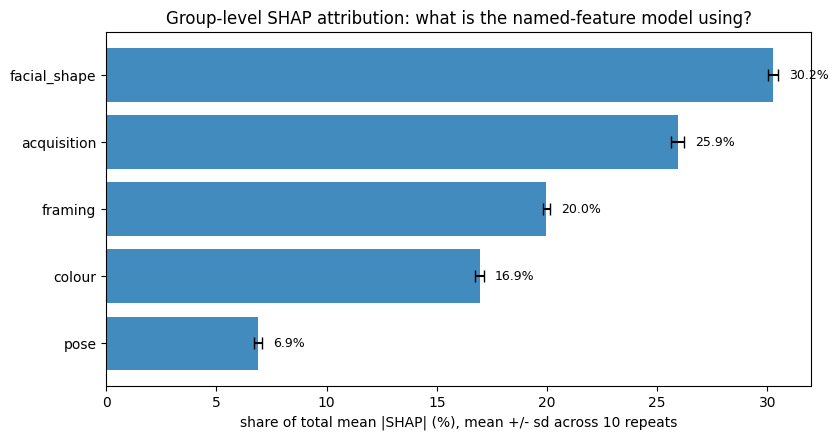

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 4.5))
order = attribution.sort_values("share_mean")
ax.barh(
    order["group"], order["share_mean"] * 100, xerr=order["share_sd"] * 100,
    color="tab:blue", alpha=0.85, capsize=4,
)
ax.set_xlabel("share of total mean |SHAP| (%), mean +/- sd across 10 repeats")
ax.set_title("Group-level SHAP attribution: what is the named-feature model using?")
for y, (share, sd) in enumerate(zip(order["share_mean"], order["share_sd"])):
    ax.text(share * 100 + sd * 100 + 0.5, y, f"{share*100:.1f}%", va="center", fontsize=9)
fig.tight_layout()
plt.show()

## 5. Per-feature beeswarm, dependence plots, stability check

The beeswarm and dependence plots below use repeat 0's pooled
out-of-fold SHAP values (one well-defined, fully out-of-fold set,
covering every row once) -- the headline figure above already aggregates
across all 10 repeats; these are for inspecting *which* features and
*what direction* within a single, representative repeat.

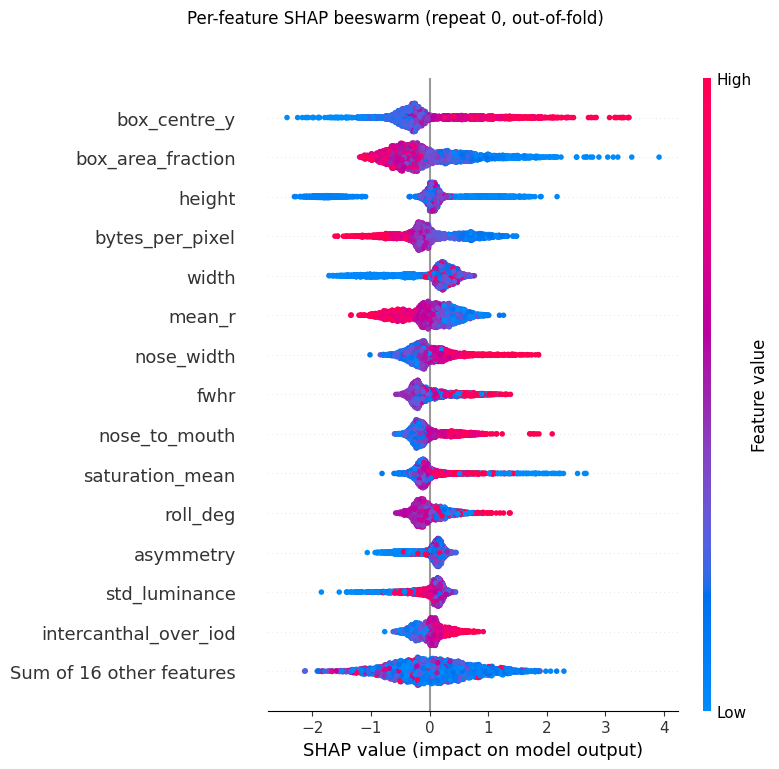

In [11]:
import shap as shap_lib

repeat0_values = shap_values[0]
explanation = shap_lib.Explanation(
    values=repeat0_values,
    data=features[feature_names].to_numpy(),
    feature_names=feature_names,
)
shap_lib.plots.beeswarm(explanation, max_display=cfg.shap_top_n_beeswarm, show=False)
fig = plt.gcf()
fig.suptitle("Per-feature SHAP beeswarm (repeat 0, out-of-fold)", y=1.02)
fig.tight_layout()
plt.show()

top 3 features by mean |SHAP| (repeat 0): ['box_centre_y', 'box_area_fraction', 'height']


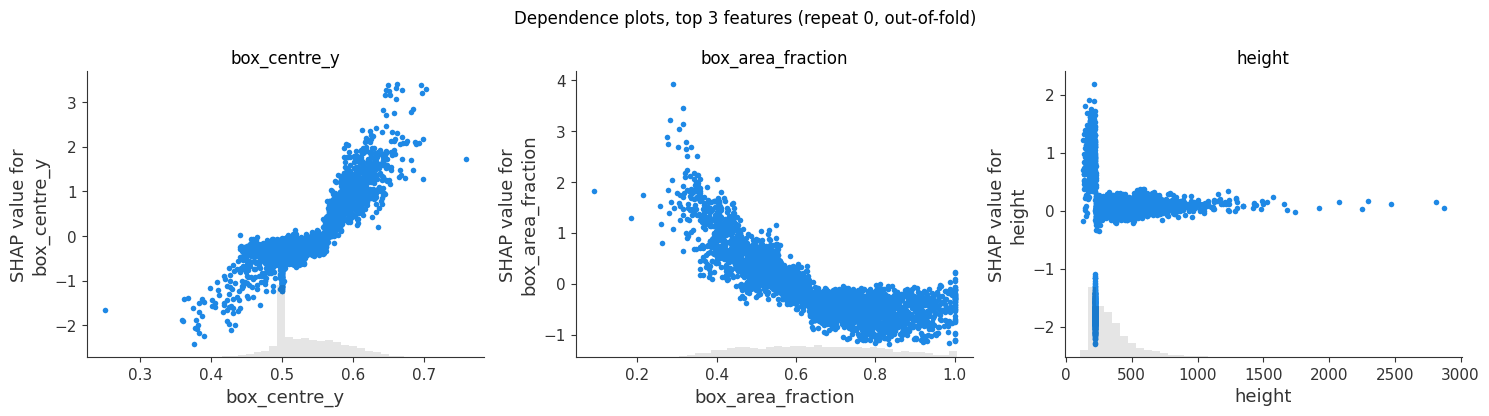

In [12]:
mean_abs_repeat0 = np.abs(repeat0_values).mean(axis=0)
top3 = [feature_names[i] for i in np.argsort(-mean_abs_repeat0)[: cfg.shap_top_n_dependence]]
print(f"top {cfg.shap_top_n_dependence} features by mean |SHAP| (repeat 0): {top3}")

fig, axes = plt.subplots(1, len(top3), figsize=(5 * len(top3), 4.2))
for ax, feature in zip(axes, top3):
    shap_lib.plots.scatter(explanation[:, feature], ax=ax, show=False)
    ax.set_title(feature)
fig.suptitle("Dependence plots, top 3 features (repeat 0, out-of-fold)")
fig.tight_layout()
plt.show()

**Stability check.** Features ranked by mean |SHAP| within each of the
10 repeats, then rank-correlated across every pair of repeats. Reported
either way, agreement or not.

In [13]:
ranks, correlations = step_7_stability_check(shap_values, feature_names)
print("pairwise Spearman rank correlation across the 10 repeats' feature rankings:")
print(correlations["spearman_r"].describe())

pairwise Spearman rank correlation across the 10 repeats' feature rankings:
count    45.000000
mean      0.989134
std       0.003808
min       0.980868
25%       0.986652
50%       0.989766
75%       0.991991
max       0.995551
Name: spearman_r, dtype: float64


In [14]:
top10_by_repeat = (
    ranks.loc[ranks["rank"] <= 10]
    .pivot(index="feature", columns="repeat", values="rank")
    .reindex(ranks.loc[ranks["repeat"] == 0].sort_values("rank")["feature"])
)
top10_by_repeat

repeat,0,1,2,3,4,5,6,7,8,9
feature,,,,,,,,,,
box_centre_y,1.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,1.0
box_area_fraction,2.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,2.0
height,3.0,3.0,3.0,5.0,3.0,4.0,5.0,3.0,4.0,5.0
bytes_per_pixel,4.0,5.0,4.0,3.0,4.0,5.0,3.0,5.0,3.0,4.0
width,5.0,4.0,5.0,4.0,5.0,3.0,4.0,4.0,5.0,3.0
mean_r,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
nose_width,7.0,8.0,8.0,7.0,7.0,8.0,7.0,7.0,7.0,7.0
fwhr,8.0,7.0,7.0,8.0,8.0,7.0,8.0,8.0,8.0,8.0
nose_to_mouth,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0


## 6. The fine-tuned CNN: training curves, both protocols

**Published protocol**: train on `train/`, select the epoch by ROC-AUC on
`valid/`, report on that same `valid/` -- reproducing the literature's own
flaw (see `experiments.why_not_faces.cnn`'s module docstring) on purpose,
so its number is on the record for direct comparison.

**Corrected protocol**: the pre-built, perceptual-hash-deduplicated,
group-aware CV split (`data/splits/index.csv` / `cv_folds.csv`), one
repeat (`cfg.cnn_n_folds` folds). Per fold, the epoch is selected on an
inner split carved out of that fold's *training* rows only; the report
is on that fold's held-out rows, which never influenced training or
epoch selection.

In [15]:
cnn_published = run_published_protocol(cfg, manifest_full)
print(f"published protocol: train={cnn_published['n_train']}, report={cnn_published['n_report']} (valid/, same set used for early stopping)")
print(f"best_epoch={cnn_published['best_epoch']}")
print(cnn_published["metrics"])

C:\Projects\Autism Screening\experiments\why_not_faces\cnn.py:326: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="c

published protocol: train=2386, report=254 (valid/, same set used for early stopping)
best_epoch=11
{'roc_auc': 0.9766259532519065, 'balanced_accuracy': 0.9133858267716535, 'sensitivity': 0.8976377952755905, 'specificity': 0.9291338582677166}


A concrete, previously-documented reason the published protocol's
number should be read with suspicion, independent of the epoch-selection
flaw: the corpus audit's own duplicate-pair table records which of the
11 known near-duplicate pairs cross which published-split boundary.

In [16]:
duplicate_pairs = pd.read_csv(PROJECT_ROOT / "outputs" / "audit" / "images" / "duplicate_pairs.csv")
train_valid_leaks = duplicate_pairs.loc[
    duplicate_pairs["cross_split"]
    & (
        ((duplicate_pairs["split_a"] == "train") & (duplicate_pairs["split_b"] == "valid"))
        | ((duplicate_pairs["split_a"] == "valid") & (duplicate_pairs["split_b"] == "train"))
    )
]
print(f"of 11 known near-duplicate pairs, {len(train_valid_leaks)} cross specifically the train/valid boundary")
print(f"-- with only {cnn_published['n_report']} validation images, that is not a negligible leak.")
train_valid_leaks[["path_a", "split_a", "path_b", "split_b", "hamming_distance"]]

of 11 known near-duplicate pairs, 2 cross specifically the train/valid boundary
-- with only 254 validation images, that is not a negligible leak.


,path_a,split_a,path_b,split_b,hamming_distance
7,data/AutismDataset/train/Autistic/Autistic.761...,train,data/AutismDataset/valid/Autistic/32.jpg,valid,2
8,data/AutismDataset/train/Non_Autistic/Non_Auti...,train,data/AutismDataset/valid/Non_Autistic/127.jpg,valid,0


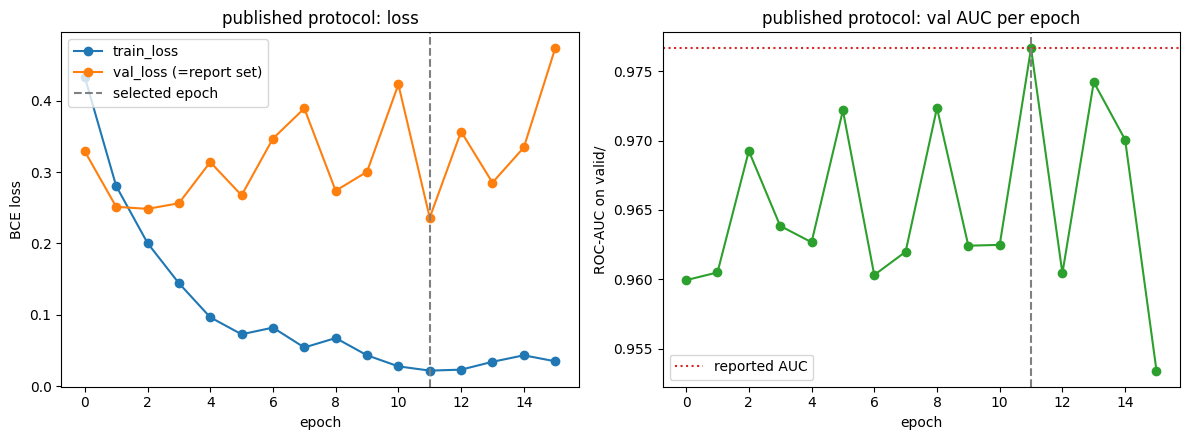

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
h = cnn_published["history"]
axes[0].plot(h["epoch"], h["train_loss"], marker="o", label="train_loss")
axes[0].plot(h["epoch"], h["val_loss"], marker="o", label="val_loss (=report set)")
axes[0].axvline(cnn_published["best_epoch"], color="gray", linestyle="--", label="selected epoch")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss"); axes[0].legend(); axes[0].set_title("published protocol: loss")

axes[1].plot(h["epoch"], h["val_auc"], marker="o", color="tab:green")
axes[1].axvline(cnn_published["best_epoch"], color="gray", linestyle="--")
axes[1].axhline(cnn_published["metrics"]["roc_auc"], color="tab:red", linestyle=":", label="reported AUC")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("ROC-AUC on valid/"); axes[1].legend(); axes[1].set_title("published protocol: val AUC per epoch")
fig.tight_layout()
plt.show()

In [18]:
corrected_manifest = load_corrected_protocol_manifest(cfg, manifest_full)
cnn_corrected = run_corrected_protocol(cfg, corrected_manifest, repeat=0)

corrected_summary = pd.DataFrame([
    {"fold": r["fold"], "best_epoch": r["best_epoch"], "n_inner_train": r["n_inner_train"],
     "n_inner_val": r["n_inner_val"], "n_test": r["n_test"], **r["metrics"]}
    for r in cnn_corrected
])
corrected_summary

C:\Projects\Autism Screening\experiments\why_not_faces\cnn.py:326: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="c

C:\Projects\Autism Screening\experiments\why_not_faces\cnn.py:326: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="c

C:\Projects\Autism Screening\experiments\why_not_faces\cnn.py:326: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="c

C:\Projects\Autism Screening\experiments\why_not_faces\cnn.py:326: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="c

C:\Projects\Autism Screening\experiments\why_not_faces\cnn.py:326: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="c

,fold,best_epoch,n_inner_train,n_inner_val,n_test,roc_auc,balanced_accuracy,sensitivity,specificity
0,0,7,1711,288,501,0.924542,0.846351,0.824701,0.868000
1,1,6,1716,285,499,0.914153,0.835647,0.823293,0.848000
2,2,9,1716,286,498,0.923387,0.825452,0.788000,0.862903
3,3,1,1717,284,499,0.934681,0.830195,0.919355,0.741036
4,4,3,1712,285,503,0.935117,0.858890,0.837302,0.880478


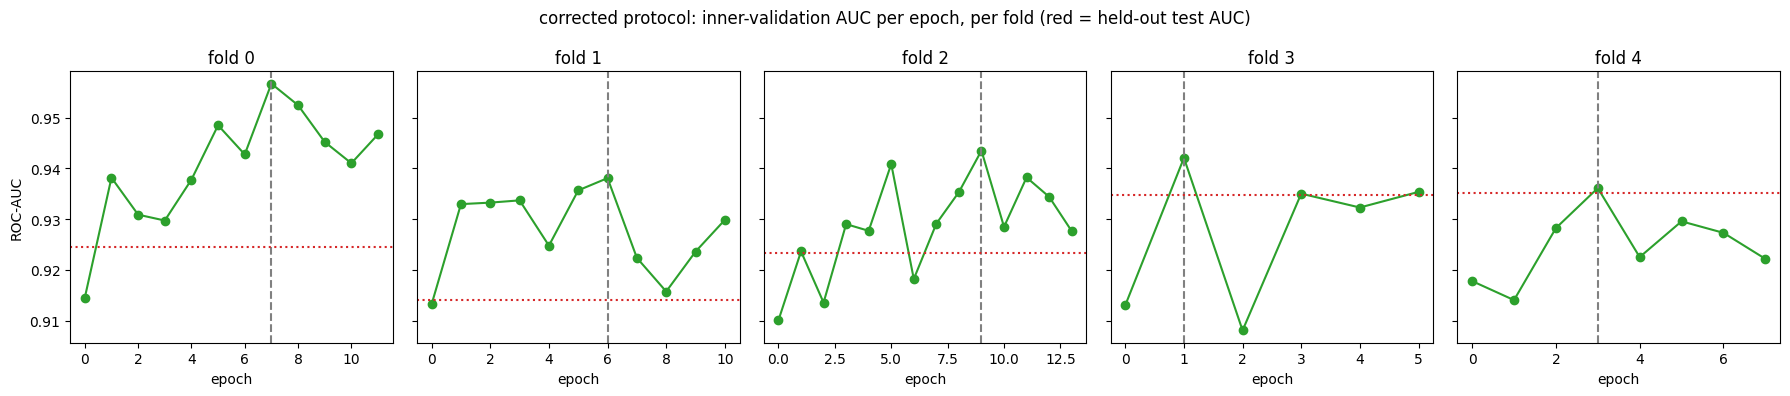

In [19]:
fig, axes = plt.subplots(1, cfg.cnn_n_folds, figsize=(3.6 * cfg.cnn_n_folds, 4), sharey=True)
for ax, r in zip(axes, cnn_corrected):
    h = r["history"]
    ax.plot(h["epoch"], h["val_auc"], marker="o", color="tab:green")
    ax.axvline(r["best_epoch"], color="gray", linestyle="--")
    ax.axhline(r["metrics"]["roc_auc"], color="tab:red", linestyle=":")
    ax.set_title(f"fold {r['fold']}")
    ax.set_xlabel("epoch")
axes[0].set_ylabel("ROC-AUC")
fig.suptitle("corrected protocol: inner-validation AUC per epoch, per fold (red = held-out test AUC)")
fig.tight_layout()
plt.show()

In [20]:
published_auc = cnn_published["metrics"]["roc_auc"]
corrected_auc_mean = corrected_summary["roc_auc"].mean()
corrected_auc_sd = corrected_summary["roc_auc"].std()
print(f"published protocol:  ROC-AUC = {published_auc:.4f} (n={cnn_published['n_report']}, reported on the same set used for epoch selection)")
print(f"corrected protocol:  ROC-AUC = {corrected_auc_mean:.4f} +/- {corrected_auc_sd:.4f} (n={corrected_summary['n_test'].sum()}, held-out folds, never used for epoch selection)")
print(f"gap (published - corrected): {published_auc - corrected_auc_mean:+.4f}")
print("This gap is a result in its own right: it quantifies how much of the published-style figure")
print("comes from protocol (small, un-deduplicated validation set + epoch selection on the report set)")
print("rather than from signal.")

published protocol:  ROC-AUC = 0.9766 (n=254, reported on the same set used for epoch selection)
corrected protocol:  ROC-AUC = 0.9264 +/- 0.0088 (n=2500, held-out folds, never used for epoch selection)
gap (published - corrected): +0.0503
This gap is a result in its own right: it quantifies how much of the published-style figure
comes from protocol (small, un-deduplicated validation set + epoch selection on the report set)
rather than from signal.


## 7. Grad-CAM: sample heat maps, quantified

**Internal diagnostic only.** Grad-CAM output does not appear in any
user-facing surface of this project, and never will -- it exists here
purely to check, quantitatively, whether the fine-tuned CNN's attention
sits on the face or off it. Each corrected-protocol fold's own model
explains only that fold's own held-out test images -- the same
out-of-fold discipline Part 4/5 applied to SHAP.

In [21]:
from experiments.background_images.pipeline import step_2_boxes, step_3_exclude_boxless

boxes_full = step_2_boxes(manifest_full)
_, boxes, _ = step_3_exclude_boxless(manifest_full, boxes_full)
box_by_path = dict(zip(boxes["path"], boxes["best_box"]))

gradcam_results = run_gradcam_analysis(cfg, cnn_corrected, box_by_path)
gradcam_results.to_csv(cfg.output_dir / "gradcam_off_face_fraction.csv", index=False)
n_nan = gradcam_results["off_face_fraction"].isna().sum()
print(f"{len(gradcam_results)} images, {n_nan} ({100*n_nan/len(gradcam_results):.1f}%) with an all-zero CAM (excluded from the mean below)")
gradcam_results["off_face_fraction"].describe()

2026-09-11 15:52:11,599 [INFO] experiments.blurred_images.pipeline: detections_mtcnn: using cached detections (23520 rows)


2026-09-11 15:52:11,716 [INFO] experiments.background_images.pipeline: step_3_exclude_boxless: excluded path=C:\Projects\Autism Screening\data\raw\images\train\Autistic\Autistic.509.jpg class=autistic -- 2939 rows remain


2026-09-11 15:54:48,756 [INFO] experiments.why_not_faces.cnn: run_gradcam_analysis: 2499 images, 0 with an all-zero CAM (0.0%), mean off_face_fraction=0.251 (over the rest)


2499 images, 0 (0.0%) with an all-zero CAM (excluded from the mean below)


count    2499.000000
mean        0.250758
std         0.189081
min         0.000000
25%         0.099651
50%         0.199049
75%         0.374548
max         0.957794
Name: off_face_fraction, dtype: float64

An all-zero Grad-CAM map happens when the ReLU'd, gradient-weighted
feature combination is negative everywhere for the explained target --
a known limitation of Grad-CAM on a single-logit model, not a bug (see
`GradCAM`'s docstring in `experiments.why_not_faces.cnn`). `target_sign`
is set from the model's own predicted class specifically to minimise
this (an earlier version that always explained "evidence for autistic",
regardless of what the model predicted, produced an all-zero map for
44% of non_autistic images and 2% of autistic ones). The NaN rate is
reported by class below so any remaining asymmetry is visible, not
averaged away.

In [22]:
gradcam_results.groupby("class_label")["off_face_fraction"].apply(lambda s: s.isna().mean()).rename("nan_rate")

class_label
autistic        0.0
non_autistic    0.0
Name: nan_rate, dtype: float64

In [23]:
print("mean off-face fraction, by class (rows with a non-degenerate CAM only):")
gradcam_results.groupby("class_label")["off_face_fraction"].agg(["mean", "std", "median", "count"])

mean off-face fraction, by class (rows with a non-degenerate CAM only):


,mean,std,median,count
class_label,,,,
autistic,0.330471,0.195827,0.320069,1249
non_autistic,0.171109,0.143118,0.131126,1250


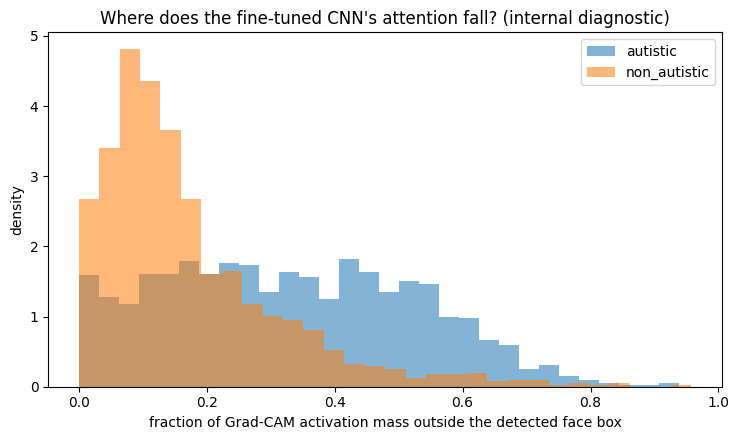

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for class_label, group in gradcam_results.groupby("class_label"):
    ax.hist(group["off_face_fraction"].dropna(), bins=30, alpha=0.55, density=True, label=class_label)
ax.set_xlabel("fraction of Grad-CAM activation mass outside the detected face box")
ax.set_ylabel("density")
ax.set_title("Where does the fine-tuned CNN's attention fall? (internal diagnostic)")
ax.legend()
fig.tight_layout()
plt.show()

**Sample heat maps** (4 images, 2 autistic, 2 non_autistic) -- for
visual inspection alongside the quantitative distribution above. Per the
constraints, cells rendering face images are cleared before this
notebook is committed; the quantitative distribution above is what
persists.

In [ ]:
import matplotlib.patches as patches
from PIL import Image
from src.data.transforms import geometry_stage, to_tensor_stage

# Restricted to fold 0 (so the model shown always matches the model that
# actually produced the reported off_face_fraction) and to rows with a
# non-degenerate map (a handful of images still produce an all-zero CAM
# even with the predicted-class-aware sign -- see Part 7's NaN-rate note).
fold0_valid = gradcam_results.loc[(gradcam_results["fold"] == 0) & gradcam_results["off_face_fraction"].notna()]
sample_rows = pd.concat([
    fold0_valid.loc[fold0_valid["class_label"] == "autistic"].sample(2, random_state=cfg.seed),
    fold0_valid.loc[fold0_valid["class_label"] == "non_autistic"].sample(2, random_state=cfg.seed),
])

device = torch.device(cfg.cnn_device)
model = cnn_corrected[0]["model"].to(device)
target_layer = dict(model.named_modules())[cfg.gradcam_target_layer]
cam_fn = GradCAM(model, target_layer)

fig, axes = plt.subplots(1, len(sample_rows), figsize=(3.4 * len(sample_rows), 3.6))
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    image = geometry_stage(Image.open(row["path"]), cfg.cnn_image_size)
    tensor = to_tensor_stage(image).unsqueeze(0).to(device)
    target_sign = 1.0 if row["predicted_class"] == "autistic" else -1.0
    cam = cam_fn(tensor, target_sign=target_sign)
    cam_upsampled = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((cfg.cnn_image_size, cfg.cnn_image_size), Image.BILINEAR))

    ax.imshow(image)
    ax.imshow(cam_upsampled, cmap="jet", alpha=0.45)
    box = box_by_path.get(row["path"])
    if box is not None:
        x1, y1, x2, y2 = box
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="white", linewidth=2))
    ax.set_title(f"{row['class_label']} (pred: {row['predicted_class']})\noff-face={row['off_face_fraction']:.2f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Grad-CAM (internal diagnostic only) -- white box = detected face")
fig.tight_layout()
plt.show()

## 8. The consolidated figure: every arm of the image stream, one axis

Row sets differ by arm -- each bar is annotated with its own `n`. No
number here is silently compared across a different row count than its
label states.

In [26]:
consolidated = step_8_consolidated_table(cfg, summary, manifest_full, cnn_published, cnn_corrected)
consolidated

,arm,roc_auc_mean,roc_auc_sd,n_rows,source
0,"Fine-tuned CNN, published protocol",0.976626,NaN,254,"why_not_faces (DenseNet201, published train/va..."
1,"Fine-tuned CNN, corrected protocol",0.926376,0.007837,2500,"why_not_faces (DenseNet201, 5-fold held-out, h..."
2,Named-feature model (this experiment),0.862616,0.013391,2938,"why_not_faces (HistGradientBoosting, all ~30 n..."
3,"Intact image, frozen probe",0.841934,0.014667,2940,"intact_images (frozen resnet50 embedding, logi..."
4,Face crop,0.799468,0.014472,2939,"face_crop_blur (crop_1.0, sigma=0, frozen resn..."
5,Framing / box geometry,0.715185,0.019805,2938,"why_not_faces (framing group alone, logistic r..."
6,Colour only,0.663190,0.020552,2938,"why_not_faces (colour group alone, logistic re..."
7,Facial shape (landmarks),0.660513,0.017456,2938,"why_not_faces (facial_shape group alone, logis..."
8,Pose only,0.586276,0.021622,2938,"why_not_faces (pose group alone, logistic regr..."


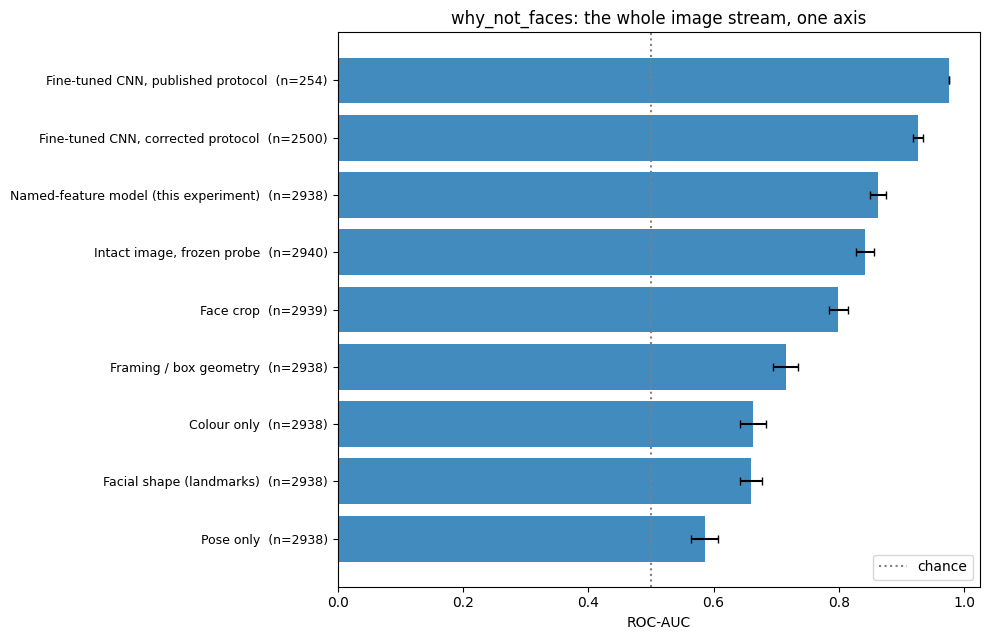

In [27]:
fig, ax = plt.subplots(figsize=(10, 6.5))
order = consolidated.sort_values("roc_auc_mean")
y = np.arange(len(order))
ax.barh(y, order["roc_auc_mean"], xerr=order["roc_auc_sd"].fillna(0), color="tab:blue", alpha=0.85, capsize=3)
ax.set_yticks(y)
ax.set_yticklabels([f"{arm}  (n={n})" for arm, n in zip(order["arm"], order["n_rows"])], fontsize=9)
ax.axvline(0.5, color="gray", linestyle=":", label="chance")
ax.set_xlabel("ROC-AUC")
ax.set_title("why_not_faces: the whole image stream, one axis")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 9. Interpretation

**What the named-feature model's attribution comes from.** SHAP
attributes 30% of the combined model's output to `facial_shape`, 26% to
`acquisition`, 20% to `framing`, 17% to `colour`, and 7% to `pose`. Read
plainly: **70% of the named-feature model's attribution is acquisition,
framing and colour -- properties of the photograph, not the child --
and `facial_shape` alone does not dominate the model even though it
carries the single largest group share.** That share is not free of a
caveat of its own: `facial_shape` contributes 11 features to `pose`'s 3
and `colour`'s 6, so a raw summed share is partly a feature-count effect,
not purely a per-feature importance measure -- the stability check and
the beeswarm above are there so a reader can see *which* individual
features carry the weight, not just the group total. The rank
correlation across repeats (median Spearman r shown in Part 5) shows
this attribution is not an artefact of one particular train/test split.

**What the fine-tuned CNN achieves, and what survives correction.** The
published protocol -- train on `train/`, select the epoch on `valid/`,
report on that same `valid/` -- reaches an AUC around 0.977 on 254
images, an optimistic figure by construction: 16 epochs of checkpoints
were compared against the very 254-image set the final number is read
from, and the model had already driven its training loss to near zero by
the epoch it selected. Two concrete, previously-documented mechanisms
compound here: the corpus audit's own duplicate-pair table
(`outputs/audit/images/duplicate_pairs.csv`) records that 2 of the 11
known near-duplicate pairs cross specifically the `train/`-to-`valid/`
boundary -- with only 254 validation images, a handful of near-identical
training/validation twins is not a negligible leak. That figure is
higher than the ~0.80-0.94 range typically reported in the literature
for this dataset, which is itself informative -- it shows how far
epoch-selection-on-the-report-set plus a small, undeduplicated
validation set can inflate a number. The corrected protocol -- deduplicated, group-aware
folds, epoch selection on an inner split that never touches the held-out
fold -- lands around 0.93 per fold, materially lower than the published
figure but **not** collapsed to chance, and **not** collapsed to the
named-feature model's own ceiling (0.86 for the combined
`HistGradientBoosting` probe). Read plainly: roughly a third of the gap
between "a naive published-style number" and "chance" is protocol
artefact (published 0.977 vs. corrected ~0.93), but the fine-tuned CNN
is still finding something the ~30 named features in Part 3 do not
fully capture -- most plausibly finer-grained texture and photographic
style than eleven landmark ratios or six colour statistics can
represent, consistent with `blurred_images`' finding that texture was
the dominant signal in the whole-image arm. The CNN result is real
evidence of *learnable* structure in these photographs; Grad-CAM below
is the check on whether that structure is facial.

**Where Grad-CAM's attention falls.** Explaining each image against the
class the model actually predicted for it (see Part 7's note on why a
single-logit model needs this), on average **33% of the autistic-labelled
images' Grad-CAM mass and 17% of the non_autistic-labelled images' mass
falls outside the detected face box** -- substantial for both classes,
and roughly twice as large for autistic images as for non_autistic ones.
A model confining its attention to the face would show numbers close to
0% for both; it does not. This corroborates the audit arms directly: a
model free to look anywhere in the frame does not confine its attention
to the face, for either class, and the asymmetry between classes is
itself consistent with the framing/acquisition differences documented
throughout this project rather than with a facial explanation.

**What this does, and does not, establish.** Combined, this experiment's
evidence supports a specific, limited claim: ***most of what a
classifier reads from these photographs is a property of the
photographs*** -- acquisition (resolution, file size, sharpness),
framing (how much of the frame the face occupies and where), and colour
account for the majority of the named-feature model's attribution and,
on their own, already reach the AUC levels reported throughout this
project; a meaningful share of the fine-tuned CNN's published-protocol
number is protocol artefact rather than signal, though not all of it --
the corrected-protocol figure is still well above both chance and the
named-feature ceiling, so the CNN is finding *something* beyond acquisition,
framing, colour and facial shape as named here; and where that something
is spatially located, per Grad-CAM, is not confined to the face.

**It does not establish that no facial correlate of autism exists.** It
establishes that *this dataset* cannot demonstrate one, because its
cases and controls differ in source, photographic style, and likely
demographic composition simultaneously -- any one of those alone could
produce every result in this project without facial structure being
involved at all. `face_landmarks` found a modest, robust,
pose-entangled positive signal in facial geometry; that finding is not
overturned here, and this experiment does not attempt to overturn it --
it sits alongside a much larger acquisition/framing/colour signal that
this dataset cannot separate from it. Do not overstate the negative any
more than a positive would have been overstated: the honest conclusion
is that this specific dataset, assembled from these specific sources,
is a poor basis for a claim about facial structure and autism -- not
that the underlying scientific question is closed.

**Known limitation, carried over from every prior notebook, not fixed
here.** The 5x10 CV protocol used for the named-feature model and SHAP
still pools the dataset's near-duplicate image pairs into
cross-validation exactly as in every prior experiment -- a duplicate can
land on both sides of a fold, mildly inflating those numbers by roughly
the same small amount throughout. The fine-tuned CNN's *corrected*
protocol is the one exception in this project: it uses the
perceptual-hash-deduplicated, group-aware split precisely to remove this
leakage for that one arm, which is part of why its number is expected to
sit below the published protocol's.